In [1]:
import os
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_182821adbddf3e75c025e9f7e250562f'

!pip install -q kaggle

In [2]:
!kaggle datasets download -d vencerlanz09/healthy-and-bleached-corals-image-classification
!unzip -q healthy-and-bleached-corals-image-classification.zip -d /content/corals

Dataset URL: https://www.kaggle.com/datasets/vencerlanz09/healthy-and-bleached-corals-image-classification
License(s): ODbL-1.0
100% 25.8M/25.8M [00:00<00:00, 64.9MB/s]



In [3]:
# confirmamos cómo están organizadas las imágenes en carpetas antes de cargarlas en el código
!find /content/corals -maxdepth 3 -type d

/content/corals
/content/corals/bleached_corals
/content/corals/healthy_corals


# **4. Cargar las imágenes**

In [4]:
import torchvision.transforms as T
from torchvision.datasets import ImageFolder

# convertimos cada imagen a tensor y le damos un tamaño fijo
# (las fotos de corales no vienen todas del mismo tamaño, por eso el Resize)
transform_basic = T.Compose([
    T.Resize((128, 128)),   # todas las imágenes al mismo tamaño
    T.ToTensor()            # convierte la imagen en tensor (igual que en TrashNet)
])

# ImageFolder lee automáticamente las carpetas como clases
full_dataset = ImageFolder(root="/content/corals", transform=transform_basic)

# Vemos qué clases detectó y cuántas imágenes hay en total
print(full_dataset.classes)
print(len(full_dataset))          # número total de imágenes

['bleached_corals', 'healthy_corals']
923


# **5. Dividir en train / validation / test**

In [5]:
import torch
from torch.utils.data import random_split

# Fijamos una "semilla" para que la división en train/val/test
# sea siempre la misma al volver a ejecutar
torch.manual_seed(123)

# Calculamos cuántas imágenes va a tener cada parte
n_total = len(full_dataset)
n_train = int(0.70 * n_total)
n_val   = int(0.15 * n_total)
n_test  = n_total - n_train - n_val  # el resto, para que sume exacto

# random_split corta el dataset en 3 partes aleatorias, esto ya venia hecho por el archivo
# que usamos en clase, asi que aquí lo hacemos manualmente
train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [n_train, n_val, n_test]
)

# Verificamos los tamaños (igual que hicimos con TrashNet)
print(len(train_dataset), len(val_dataset), len(test_dataset))

646 138 139


# **6. DataLoaders y visualización de ejemplos**

In [6]:
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# DataLoaders: organizan las imágenes en lotes (batches) y las mezclan
# (mismo concepto que usaste con TrashNet)
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

# device: usa GPU si está disponible (igual que en el Taller 4)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


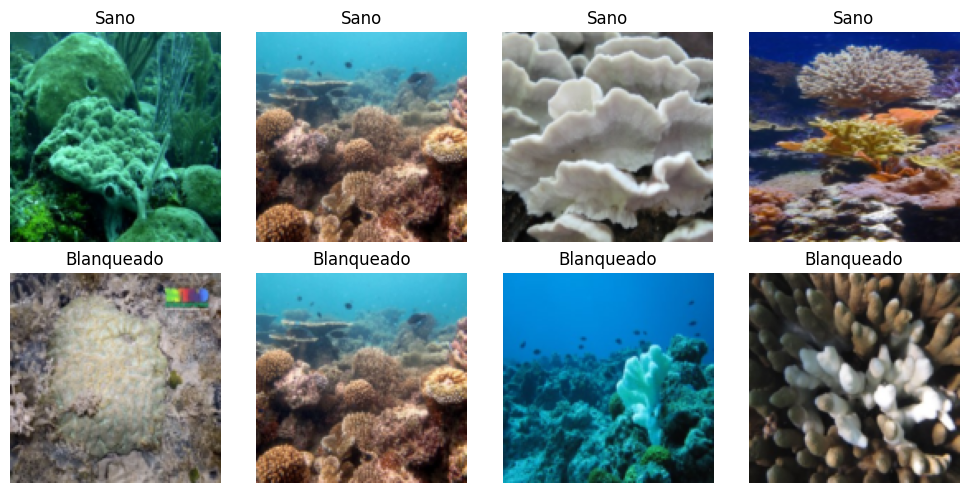

In [7]:
def show_coral_examples(dataset, classes):
    # Buscamos 4 ejemplos de cada clase
    sano = []
    danado = []

    for i in range(len(dataset)):
        x, y = dataset[i]
        if y == classes.index("healthy_corals") and len(sano) < 4:
            sano.append(x)
        elif y == classes.index("bleached_corals") and len(danado) < 4:
            danado.append(x)
        if len(sano) == 4 and len(danado) == 4:
            break

    plt.figure(figsize=(10, 5))
    imgs = sano + danado
    titles = ["Sano"] * 4 + ["Blanqueado"] * 4

    for i, img in enumerate(imgs):
        plt.subplot(2, 4, i + 1)
        # permute reordena canales para que matplotlib pueda mostrar la imagen a color
        plt.imshow(img.permute(1, 2, 0))
        plt.title(titles[i])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_coral_examples(full_dataset, full_dataset.classes)

# **7. Construir la CNN**

In [8]:
import torch.nn as nn

# Misma arquitectura SimpleCNN del Taller 4
# (Conv2D + ReLU + Pooling, 3 veces, y clasificador al final)
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),  # 3 canales porque ahora es a color (RGB), no escala de grises
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# num_classes = 2 (sano / blanqueado)
num_classes = len(full_dataset.classes)
model_coral = SimpleCNN(num_classes=num_classes).to(device)
print(model_coral)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=64, out_features=2, bias=True)
  )
)


# **8. Funciones de entrenamiento y evaluación**

In [9]:
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

# Convierte las salidas del modelo en probabilidades (igual que en el Taller 4)
def logits_to_probs(logits):
    return torch.softmax(logits, dim=1)[:, 1]

@torch.no_grad()  # no calculamos gradientes aquí, solo evaluamos
def evaluate(model, loader):
    model.eval()  # modo evaluación (apaga dropout si hubiera)
    all_labels, all_probs, all_preds = [], [], []

    for x, y in loader:
        x, y = x.to(device), y.to(device).long()
        logits = model(x)
        probs = logits_to_probs(logits)
        preds = (probs >= 0.5).long()

        all_labels.append(y.cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())

    y_true = np.concatenate(all_labels)
    y_prob = np.concatenate(all_probs)
    y_pred = np.concatenate(all_preds)

    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    return acc, auc, y_true, y_pred, y_prob

# Entrena el modelo durante una época (una pasada completa por los datos)
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()  # modo entrenamiento
    losses = []
    for x, y in loader:
        x, y = x.to(device), y.to(device).long()

        optimizer.zero_grad()      # reinicia gradientes
        logits = model(x)          # predicción del modelo
        loss = criterion(logits, y)  # qué tan mal predijo
        loss.backward()            # calcula gradientes
        optimizer.step()           # ajusta los pesos

        losses.append(loss.item())
    return float(np.mean(losses))

# **9. Entrenamos el modelo**

In [10]:
import matplotlib.pyplot as plt

# CrossEntropyLoss: mide qué tan lejos están las predicciones de la clase real
# (igual que en el Taller 4)
criterion = nn.CrossEntropyLoss()

# Adam: optimizador que ajusta los pesos del modelo
optimizer = torch.optim.Adam(model_coral.parameters(), lr=1e-3)

epochs = 10
history_coral = {"train_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model_coral, train_loader, optimizer, criterion)
    val_acc, val_auc, _, _, _ = evaluate(model_coral, val_loader)

    history_coral["train_loss"].append(train_loss)
    history_coral["val_acc"].append(val_acc)
    history_coral["val_auc"].append(val_auc)

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")

Epoch 01 | train_loss=0.6880 | val_acc=0.5072 | val_auc=0.5975
Epoch 02 | train_loss=0.6818 | val_acc=0.5217 | val_auc=0.6279
Epoch 03 | train_loss=0.6812 | val_acc=0.5145 | val_auc=0.6588
Epoch 04 | train_loss=0.6672 | val_acc=0.5362 | val_auc=0.6813
Epoch 05 | train_loss=0.6484 | val_acc=0.6594 | val_auc=0.7265
Epoch 06 | train_loss=0.6100 | val_acc=0.6232 | val_auc=0.7395
Epoch 07 | train_loss=0.5792 | val_acc=0.7101 | val_auc=0.7870
Epoch 08 | train_loss=0.5840 | val_acc=0.6884 | val_auc=0.7769
Epoch 09 | train_loss=0.5723 | val_acc=0.6449 | val_auc=0.7735
Epoch 10 | train_loss=0.5613 | val_acc=0.7174 | val_auc=0.7876


# **10. Graficar las curvas de entrenamiento**

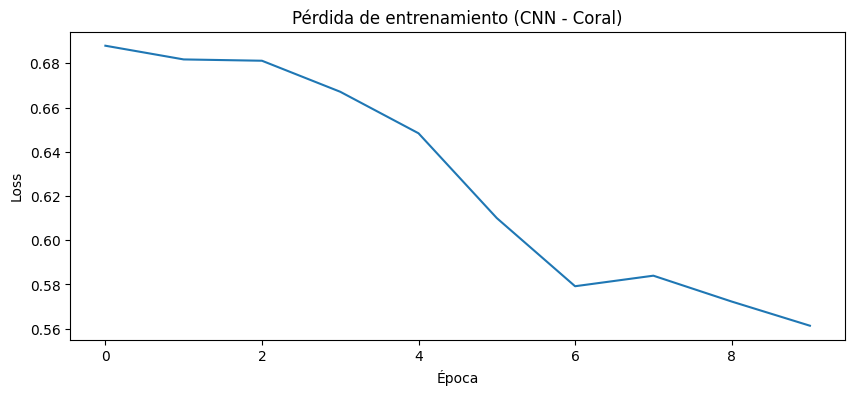

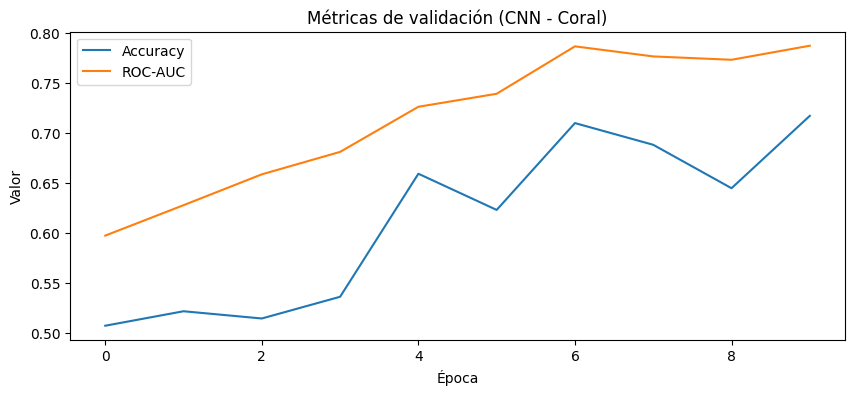

In [11]:
# Gráfica de la pérdida de entrenamiento por época
plt.figure(figsize=(10, 4))
plt.plot(history_coral["train_loss"])
plt.title("Pérdida de entrenamiento (CNN - Coral)")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.show()

# Gráfica de accuracy y ROC-AUC de validación por época
plt.figure(figsize=(10, 4))
plt.plot(history_coral["val_acc"], label="Accuracy")
plt.plot(history_coral["val_auc"], label="ROC-AUC")
plt.title("Métricas de validación (CNN - Coral)")
plt.xlabel("Época")
plt.ylabel("Valor")
plt.legend()
plt.show()

# **11. Evaluación final en el conjunto de prueba**

In [12]:
# Evaluación final sobre test (datos que el modelo nunca vio)
test_acc, test_auc, y_true, y_pred, y_prob = evaluate(model_coral, test_loader)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test ROC-AUC:  {test_auc:.4f}")
print()
print(classification_report(y_true, y_pred, digits=4))

cm = confusion_matrix(y_true, y_pred)
cm

Test accuracy: 0.7266
Test ROC-AUC:  0.7750

              precision    recall  f1-score   support

           0     0.6750    0.8182    0.7397        66
           1     0.7966    0.6438    0.7121        73

    accuracy                         0.7266       139
   macro avg     0.7358    0.7310    0.7259       139
weighted avg     0.7389    0.7266    0.7252       139



array([[54, 12],
       [26, 47]])

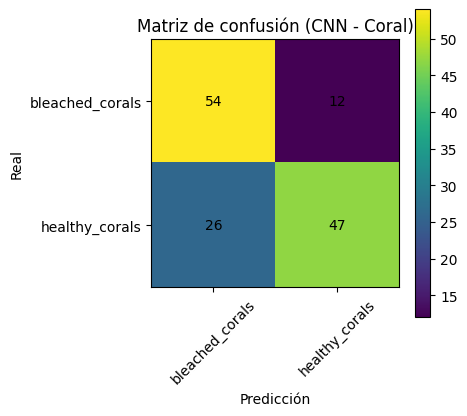

In [13]:
plt.figure(figsize=(4, 4))
plt.imshow(cm)
plt.title("Matriz de confusión (CNN - Coral)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.xticks([0, 1], full_dataset.classes, rotation=45)
plt.yticks([0, 1], full_dataset.classes)
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.colorbar()
plt.show()

# **12. Data augmentation**

In [15]:
transform_aug = T.Compose([
    T.Resize((128, 128)),
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor()
])

# Creamos OTRA instancia de ImageFolder, pero con el transform de augmentation
full_dataset_aug = ImageFolder(root="/content/corals", transform=transform_aug)

# Reutilizamos los MISMOS índices de train_dataset (el que ya generó random_split)
# así entrenamos con las mismas imágenes, solo que con augmentation aplicado
train_dataset_aug = torch.utils.data.Subset(full_dataset_aug, train_dataset.indices)

train_loader_aug = DataLoader(
    train_dataset_aug,
    batch_size=batch_size,
    shuffle=True
)

# **12.1. Entrenar un nuevo modelo con augmentation**

In [16]:
model_coral_aug = SimpleCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_coral_aug.parameters(), lr=1e-3)

epochs = 10
history_coral_aug = {"train_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model_coral_aug, train_loader_aug, optimizer, criterion)
    val_acc, val_auc, _, _, _ = evaluate(model_coral_aug, val_loader)

    history_coral_aug["train_loss"].append(train_loss)
    history_coral_aug["val_acc"].append(val_acc)
    history_coral_aug["val_auc"].append(val_auc)

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")

Epoch 01 | train_loss=0.6835 | val_acc=0.4928 | val_auc=0.6834
Epoch 02 | train_loss=0.6685 | val_acc=0.6087 | val_auc=0.7145
Epoch 03 | train_loss=0.6458 | val_acc=0.5797 | val_auc=0.7137
Epoch 04 | train_loss=0.6397 | val_acc=0.6884 | val_auc=0.7487
Epoch 05 | train_loss=0.6147 | val_acc=0.6957 | val_auc=0.7557
Epoch 06 | train_loss=0.5995 | val_acc=0.6377 | val_auc=0.7534
Epoch 07 | train_loss=0.5990 | val_acc=0.6957 | val_auc=0.7716
Epoch 08 | train_loss=0.5965 | val_acc=0.6884 | val_auc=0.7622
Epoch 09 | train_loss=0.5862 | val_acc=0.6812 | val_auc=0.7637
Epoch 10 | train_loss=0.5698 | val_acc=0.6957 | val_auc=0.7597


# **12.2. Comparación con el modelo sin augmentation**

In [17]:
test_acc_coral_aug, test_auc_coral_aug, _, _, _ = evaluate(model_coral_aug, test_loader)

print(f"Sin augmentation  | test_acc={test_acc:.4f} | test_auc={test_auc:.4f}")
print(f"Con augmentation  | test_acc={test_acc_coral_aug:.4f} | test_auc={test_auc_coral_aug:.4f}")

Sin augmentation  | test_acc=0.7266 | test_auc=0.7750
Con augmentation  | test_acc=0.6835 | test_auc=0.7860


--> a diferencia de TrashNet, el augmentation no mostró una mejora consistente en este dataset.                                                                        
--> el accuracy bajó un poco (0.7266 → 0.6835) pero el ROC-AUC subió levemente (0.7750 → 0.7860).

# **13. Transfer Learning**

In [18]:
# En vez de entrenar una CNN desde cero, reutilizamos una red (ResNet18)
# ya entrenada con millones de imágenes (ImageNet) y la adaptamos a
# nuestro problema: coral sano vs blanqueado

import torchvision.models as models

# ResNet18 espera imágenes de 224x224, normalizadas con los valores
# estadísticos de ImageNet (con los que fue entrenada originalmente)
transform_tl = T.Compose([
    T.Resize((224, 224)),
    T.RandomRotation(degrees=10),        # seguimos usando augmentation leve
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],   # normalización estándar de ImageNet
                std=[0.229, 0.224, 0.225])
])

# Para validación/test NO usamos augmentation, solo resize + normalize
# (el modelo se evalúa con las imágenes "reales", sin alteraciones)
transform_tl_eval = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

# Volvemos a cargar el dataset completo, pero con los transforms de transfer learning
full_dataset_tl_train = ImageFolder(root="/content/corals", transform=transform_tl)
full_dataset_tl_eval  = ImageFolder(root="/content/corals", transform=transform_tl_eval)

# Reutilizamos los MISMOS índices que generó random_split al inicio,
# así entrenamos/evaluamos con las mismas imágenes de siempre (comparación justa)
train_dataset_tl = torch.utils.data.Subset(full_dataset_tl_train, train_dataset.indices)
val_dataset_tl   = torch.utils.data.Subset(full_dataset_tl_eval, val_dataset.indices)
test_dataset_tl  = torch.utils.data.Subset(full_dataset_tl_eval, test_dataset.indices)

train_loader_tl = DataLoader(train_dataset_tl, batch_size=batch_size, shuffle=True)
val_loader_tl   = DataLoader(val_dataset_tl,   batch_size=batch_size, shuffle=False)
test_loader_tl  = DataLoader(test_dataset_tl,  batch_size=batch_size, shuffle=False)

# **13.1. Construir el modelo preentrenado (etapa 1: solo entrenar la última capa)**

In [19]:
resnet_coral = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Reemplazamos la última capa (fc) para que tenga 2 salidas (sano / blanqueado)
# en vez de las 1000 clases originales de ImageNet
in_features = resnet_coral.fc.in_features
resnet_coral.fc = nn.Linear(in_features, num_classes)
resnet_coral = resnet_coral.to(device)

# Congelamos TODAS las capas del extractor de características:
# no queremos que "olviden" lo que ya aprendieron de ImageNet
for name, param in resnet_coral.named_parameters():
    param.requires_grad = False

# Descongelamos solo la capa final, que es la única que vamos a entrenar por ahora
for param in resnet_coral.fc.parameters():
    param.requires_grad = True

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 106MB/s]


In [20]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(resnet_coral.fc.parameters(), lr=1e-3)

epochs = 6
history_tl_stage1 = {"train_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(resnet_coral, train_loader_tl, optimizer, criterion)
    val_acc, val_auc, _, _, _ = evaluate(resnet_coral, val_loader_tl)

    history_tl_stage1["train_loss"].append(train_loss)
    history_tl_stage1["val_acc"].append(val_acc)
    history_tl_stage1["val_auc"].append(val_auc)

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")

Epoch 01 | train_loss=0.6971 | val_acc=0.6232 | val_auc=0.6771
Epoch 02 | train_loss=0.6063 | val_acc=0.6014 | val_auc=0.7504
Epoch 03 | train_loss=0.5384 | val_acc=0.6957 | val_auc=0.7872
Epoch 04 | train_loss=0.5093 | val_acc=0.7029 | val_auc=0.7943
Epoch 05 | train_loss=0.5137 | val_acc=0.7391 | val_auc=0.8038
Epoch 06 | train_loss=0.4919 | val_acc=0.7246 | val_auc=0.8088


# **13.2. Fine-tuning (etapa 2: descongelar las últimas capas)**

In [21]:
# Descongelamos "layer4" (el último bloque convolucional) además de "fc",
# para que la red ajuste un poco sus filtros más profundos a las texturas
# específicas del coral, no solo la clasificación final
for name, param in resnet_coral.named_parameters():
    if name.startswith("layer4") or name.startswith("fc"):
        param.requires_grad = True

trainable_params = [p for p in resnet_coral.parameters() if p.requires_grad]

# lr más bajo que antes: aquí solo queremos ajustes finos, no re-aprender desde cero
optimizer = torch.optim.Adam(trainable_params, lr=1e-4)

epochs = 4
history_tl_stage2 = {"train_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(resnet_coral, train_loader_tl, optimizer, criterion)
    val_acc, val_auc, _, _, _ = evaluate(resnet_coral, val_loader_tl)

    history_tl_stage2["train_loss"].append(train_loss)
    history_tl_stage2["val_acc"].append(val_acc)
    history_tl_stage2["val_auc"].append(val_auc)

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")

Epoch 01 | train_loss=0.4908 | val_acc=0.7536 | val_auc=0.8702
Epoch 02 | train_loss=0.2825 | val_acc=0.7754 | val_auc=0.8723
Epoch 03 | train_loss=0.2155 | val_acc=0.7464 | val_auc=0.8697
Epoch 04 | train_loss=0.1726 | val_acc=0.7464 | val_auc=0.8750


# **13.3. Evaluación en test**

In [22]:
test_acc_tl, test_auc_tl, y_true_tl, y_pred_tl, y_prob_tl = evaluate(resnet_coral, test_loader_tl)
print(f"Transfer learning | test_acc={test_acc_tl:.4f} | test_auc={test_auc_tl:.4f}")
print()
print(classification_report(y_true_tl, y_pred_tl, digits=4))

cm_tl = confusion_matrix(y_true_tl, y_pred_tl)
cm_tl

Transfer learning | test_acc=0.7626 | test_auc=0.8651

              precision    recall  f1-score   support

           0     0.6988    0.8788    0.7785        66
           1     0.8571    0.6575    0.7442        73

    accuracy                         0.7626       139
   macro avg     0.7780    0.7682    0.7614       139
weighted avg     0.7820    0.7626    0.7605       139



array([[58,  8],
       [25, 48]])

# **13.4. Comparación global**

In [23]:
print("Resumen de resultados en test (Coral)")
print(f"CNN desde cero (sin aug)   | acc={test_acc:.4f} | auc={test_auc:.4f}")
print(f"CNN desde cero (con aug)   | acc={test_acc_coral_aug:.4f} | auc={test_auc_coral_aug:.4f}")
print(f"Transfer learning (ResNet) | acc={test_acc_tl:.4f} | auc={test_auc_tl:.4f}")

Resumen de resultados en test (Coral)
CNN desde cero (sin aug)   | acc=0.7266 | auc=0.7750
CNN desde cero (con aug)   | acc=0.6835 | auc=0.7860
Transfer learning (ResNet) | acc=0.7626 | auc=0.8651


# **14. Interpretabilidad con Grad-CAM**

In [24]:
# Grad-CAM genera un "mapa de calor" sobre la imagen, mostrando qué zonas
# influyeron más en la predicción del modelo. Es la misma técnica que usaste
# en el Taller 4 con el modelo de TrashNet (ResNet18), aquí solo cambiamos
# el modelo y el dataset por los de coral.

import torch

def grad_cam(model, image_tensor, target_class=None):
    model.eval()
    image_tensor = image_tensor.to(device)

    activations = {}
    gradients = {}

    # Guardamos la salida de la última capa convolucional (layer4)
    def forward_hook(module, inp, out):
        activations["value"] = out

    # Guardamos el gradiente que llega a esa misma capa
    def backward_hook(module, grad_in, grad_out):
        gradients["value"] = grad_out[0]

    # "Enganchamos" los hooks a layer4, el último bloque convolucional de ResNet18
    # (el mismo que descongelamos en el fine-tuning, paso 13.2)
    handle_fwd = model.layer4.register_forward_hook(forward_hook)
    handle_bwd = model.layer4.register_full_backward_hook(backward_hook)

    # Pasamos la imagen por el modelo (agregamos dimensión de batch con unsqueeze)
    output = model(image_tensor.unsqueeze(0))
    if target_class is None:
        target_class = output.argmax(dim=1).item()

    # Backward solo sobre la clase que nos interesa explicar
    model.zero_grad()
    output[0, target_class].backward()

    # Promediamos los gradientes por canal: esto nos dice qué tan importante
    # fue cada "filtro" de layer4 para la predicción
    grads = gradients["value"][0]
    acts = activations["value"][0]
    weights = grads.mean(dim=(1, 2))  # promedio espacial por canal

    # Combinamos los mapas de activación ponderados por su importancia
    cam = torch.zeros(acts.shape[1:], device=device)
    for i, w in enumerate(weights):
        cam += w * acts[i]

    # ReLU: solo nos interesan las zonas que contribuyen positivamente
    cam = torch.relu(cam)
    cam = cam.detach().cpu().numpy()
    cam = cam / (cam.max() + 1e-8)  # normalizamos entre 0 y 1 para visualizar

    handle_fwd.remove()
    handle_bwd.remove()

    return cam, target_class

# **14.1. Visualizar un ejemplo**

<sys>:0: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


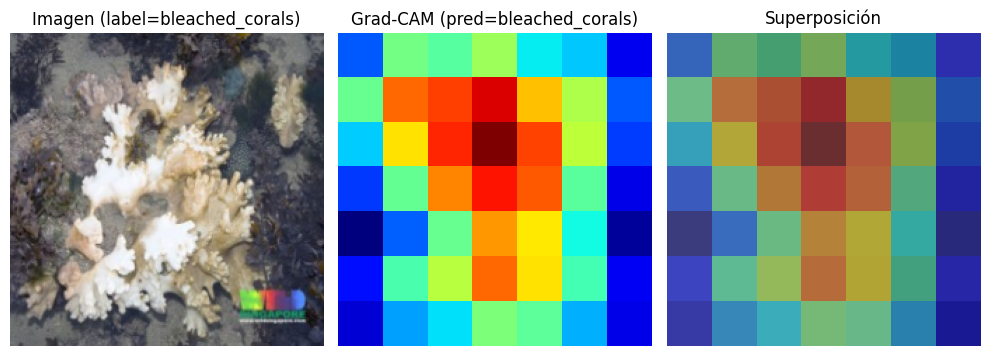

In [25]:
# Usamos el modelo con transfer learning (resnet_coral), que fue el que mejor resultado dio

idx = 0
x, y = test_dataset_tl[idx]
cam, pred_class = grad_cam(resnet_coral, x)

# Convertimos la imagen de tensor a formato que matplotlib pueda mostrar
# permute reordena los canales (C,H,W) -> (H,W,C)
# Como esta imagen está normalizada con los valores de ImageNet, la "desnormalizamos"
# para que se vea con colores reales
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
img = (x * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title(f"Imagen (label={full_dataset.classes[int(y)]})")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cam, cmap="jet")
plt.title(f"Grad-CAM (pred={full_dataset.classes[pred_class]})")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img)
plt.imshow(cam, cmap="jet", alpha=0.5)  # superponemos el mapa de calor sobre la imagen original
plt.title("Superposición")
plt.axis("off")

plt.tight_layout()
plt.show()

# **14.2. Grad-CAM con un ejemplo de coral sano**

In [26]:
# Buscamos el primer índice del conjunto de test que sea "healthy_corals"
# para comparar contra el caso "bleached_corals" que ya vimos

healthy_idx = full_dataset.classes.index("healthy_corals")

idx_sano = None
for i in range(len(test_dataset_tl)):
    _, y = test_dataset_tl[i]
    if int(y) == healthy_idx:
        idx_sano = i
        break

print(f"Índice de un coral sano en test: {idx_sano}")

Índice de un coral sano en test: 1


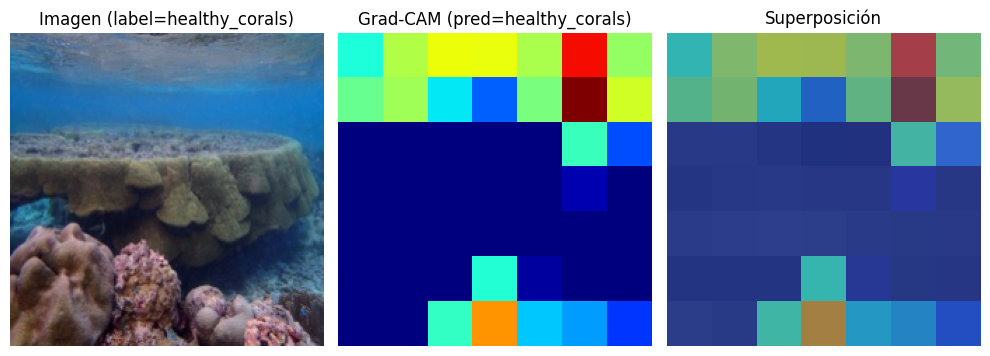

In [27]:
# Aplicamos Grad-CAM sobre ese ejemplo, igual que hicimos con el coral blanqueado

x, y = test_dataset_tl[idx_sano]
cam, pred_class = grad_cam(resnet_coral, x)

# Desnormalizamos la imagen para poder verla con colores reales
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
img = (x * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title(f"Imagen (label={full_dataset.classes[int(y)]})")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cam, cmap="jet")
plt.title(f"Grad-CAM (pred={full_dataset.classes[pred_class]})")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img)
plt.imshow(cam, cmap="jet", alpha=0.5)
plt.title("Superposición")
plt.axis("off")

plt.tight_layout()
plt.show()

# **15. Guardar el modelo**

In [28]:
# Guardamos el modelo con transfer learning (el de mejor desempeño)
# para poder reutilizarlo después sin tener que reentrenarlo desde cero

import os

os.makedirs("models", exist_ok=True)

torch.save(resnet_coral.state_dict(), "models/resnet_coral_transfer.pth")

print("Modelo guardado en models/resnet_coral_transfer.pth")

Modelo guardado en models/resnet_coral_transfer.pth
